
# RandomForest para el dataset social_media_mental_health.csv
RandomForest para el dataset social_media_mental_health.csv

Mounted at /content/drive
Accuracy Global en Test: 54.66%

Reporte de Clasificación Detallado:

                   precision    recall  f1-score   support

             MILD       0.41      0.24      0.30       476
         MODERATE       0.36      0.51      0.42       273
MODERATELY SEVERE       0.13      0.19      0.15        78
     NONE-MINIMAL       0.75      0.79      0.77       777
           SEVERE       0.00      0.00      0.00         4

         accuracy                           0.55      1608
        macro avg       0.33      0.35      0.33      1608
     weighted avg       0.55      0.55      0.54      1608



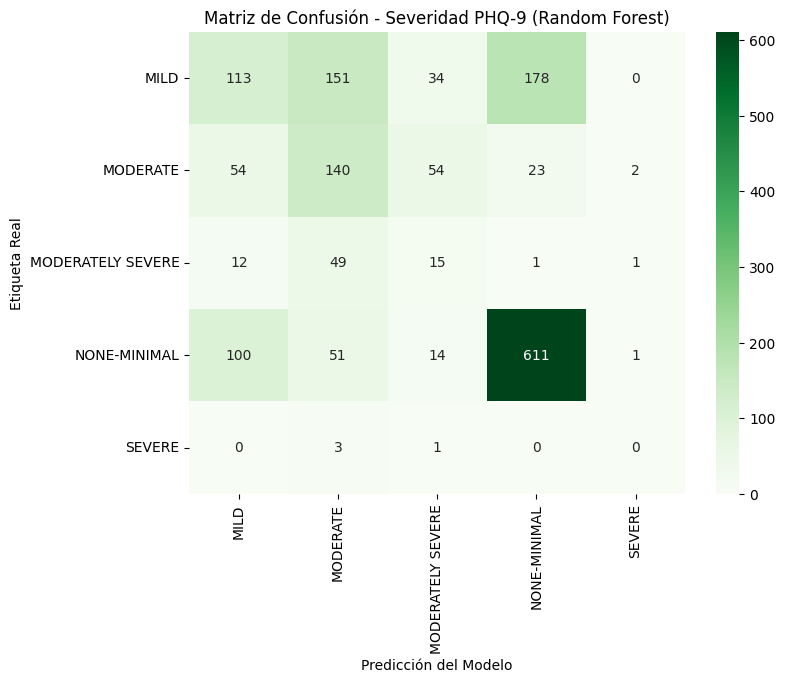

In [1]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS Y MÓDULOS NECESARIOS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Módulos de Scikit-Learn para preprocesamiento, modelado y evaluación
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==============================================================================
# 1. MONTAJE DE GOOGLE DRIVE Y CARGA DE DATOS
# ==============================================================================
# Intentamos montar Google Drive si no se encuentra activo
try:
    drive.mount('/content/drive')
except Exception as e:
    print("Drive ya se encuentra montado o requiere reconexión desde el panel lateral.")

# Rutas absolutas a la estructura de archivos en Google Drive (Ajusta la carpeta según tu Drive)
train_path = '/content/drive/My Drive/proyecto dataset/ML/MA/dataset-train.csv'
test_path = '/content/drive/My Drive/proyecto dataset/ML/MA/dataset-test.csv'

# Carga de datasets en DataFrames de Pandas
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# ==============================================================================
# 2. SEPARACIÓN DE FEATURES (X) Y VARIABLE OBJETIVO (y)
# ==============================================================================
# Definimos la variable objetivo a predecir
target_col = 'PHQ_9_Severity'

# Importante: Excluimos 'User_ID' (identificador) y 'PHQ_9_Score' (puntaje directo)
# para evitar Data Leakage (fuga trivial de la etiqueta objetivo)
cols_to_drop = ['User_ID', 'PHQ_9_Score','GAD_7_Score','GAD_7_Severity', target_col]

X_train = train.drop(columns=cols_to_drop)
y_train = train[target_col]

X_test = test.drop(columns=cols_to_drop)
y_test = test[target_col]

# ==============================================================================
# 3. IDENTIFICACIÓN Y CONVERSIÓN DE TIPOS DE DATOS
# ==============================================================================
# Seleccionamos las columnas según su tipo de dato original
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()

# Convertimos explícitamente las columnas booleanas a enteros binarios (0 y 1)
for col in bool_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)
    num_cols.append(col)  # Pasan a la lista de variables numéricas

# ==============================================================================
# 4. CONFIGURACIÓN DEL PREPROCESADOR (COLUMN TRANSFORMER)
# ==============================================================================
# Definimos el Pipeline de transformaciones:
# - 'num': Aplica estandarización Z-Score (StandardScaler) a las numéricas.
# - 'cat': Aplica codificación OneHotEncoder a las variables categóricas.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# ==============================================================================
# 5. PIPELINE DEL MODELO RANDOM FOREST CLASSIFIER
# ==============================================================================
# Encapsulamos preprocesamiento y modelo para garantizar reproducibilidad
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,        # Número de árboles en el ensemble
        max_depth=12,            # Control de profundidad para prevenir overfitting
        min_samples_split=5,     # Mínimo de muestras para dividir un nodo
        random_state=46,         # Semilla aleatoria para reproducibilidad
        class_weight='balanced'  # Balanceo de peso para compensar clases minoritarias
    ))
])

# ==============================================================================
# 6. ENTRENAMIENTO Y PREDICCIÓN
# ==============================================================================
# Entrenamos el modelo con los datos de entrenamiento
rf_pipeline.fit(X_train, y_train)

# Predecimos sobre el conjunto de prueba
y_pred = rf_pipeline.predict(X_test)

# ==============================================================================
# 7. EVALUACIÓN DE MÉTRICAS Y VISUALIZACIÓN
# ==============================================================================
print("=" * 60)
print(f"Accuracy Global en Test: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("=" * 60)
print("\nReporte de Clasificación Detallado:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf_pipeline.classes_)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=rf_pipeline.classes_,
    yticklabels=rf_pipeline.classes_
)

plt.title('Matriz de Confusión - Severidad PHQ-9 (Random Forest)', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=10)
plt.ylabel('Etiqueta Real', fontsize=10)
plt.show()